RAG with Persistance Memory using Langgraph

In [37]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
load_dotenv()


os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000024CA9925C10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000024CAC228C20>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [38]:
from langchain_huggingface import HuggingFaceEmbeddings
embedding = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
embedding

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

doc ingestion and processing

In [39]:
import bs4
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing_extensions import List,TypedDict

In [40]:
loader = WebBaseLoader(
    web_path=("https://lilianweng.github.io/posts/2023-06-23-agent/"),
    bs_kwargs=dict(
        parse_only = bs4.SoupStrainer(
            class_ = ("post-content","post-title","post-header")
        )
    )
)
docs = loader.load()
docs

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [41]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
splits = splitter.split_documents(docs)
print(f"No of chunks: {len(splits)}")

No of chunks: 63


In [42]:
from langchain_community.vectorstores import FAISS
vs = FAISS.from_documents(
    documents=splits,
    embedding=embedding
)
vs

In [43]:
from langchain.tools import tool

@tool()
def retrieve(query: str):
    """Retrieve the information related to the query"""
    retrieved_docs = vs.similarity_search(query,k=2)
    serialized = "\n\n".join(
        f"Source: {doc.metadata} \nContent: {doc.page_content}"
        for doc in retrieved_docs
    )
    return serialized,retrieved_docs

In [44]:
from langchain_core.messages import SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END,MessagesState,StateGraph
from langgraph.prebuilt import ToolNode,tools_condition

node definitions

In [45]:
def query_or_respond(state: MessagesState):
    """Generate tool call for retrieval or respond"""
    llm_with_tools = llm.bind_tools([retrieve])
    response = llm_with_tools.invoke(state["messages"])
    return {
        "messages": [response]
    }

In [46]:
tools = ToolNode([retrieve])
tools

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'retrieve': StructuredTool(name='retrieve', description='Retrieve the information related to the query', args_schema=<class 'langchain_core.utils.pydantic.retrieve'>, func=<function retrieve at 0x0000024CAE892F20>)}, _injected_args={'retrieve': _InjectedArgs(state={}, store=None, runtime=None, all_injected_keys=set(), _optional_state_args=set())}, _handle_tool_errors=<function _default_handle_tool_errors at 0x0000024CA9802200>, _messages_key='messages', _wrap_tool_call=None, _awrap_tool_call=None)

In [47]:
def generate(state: MessagesState):
    """Generate answer"""
    recent_tool_msgs = []
    for msg in reversed(state['messages']):
        if msg.type == "tool":
            recent_tool_msgs.append(msg)
        else:
            break
    tool_messages = recent_tool_msgs[::-1]

    docs_content = "\n\n".join(doc.content for doc in tool_messages)
    system_message_content = f"""
        "You are an assitant for question-answering tasks."
        "Use the following pieces of retrieved context to answer"
        "the question. If you dont know the answer, say that you"
        "dont know. Use three sentences maximum and keep the "
        "answer concise"
        "\n\n"
        "{docs_content}" """
    conversation_messages = [
        message for message in state["messages"]
        if message.type in ("human","system")
        or (message.type == "ai" and not message.tool_calls)
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages
    response = llm.invoke(prompt)
    return {
        "messages": [response]
    }

Graph Building

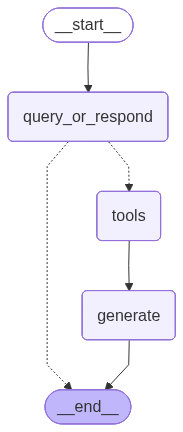

In [48]:
graph_builder = StateGraph(MessagesState)

graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)

graph_builder.set_entry_point("query_or_respond")
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END,"tools":"tools"}
)
graph_builder.add_edge("tools","generate")
graph_builder.add_edge("generate",END)

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
graph

unique thread to keep track of mmry

In [49]:
config = {"configurable":{"thread_id":"abc123"}}

In [50]:
input_message = "Hello"
for step in graph.stream(
    {"messages": [{"role":"user","content":input_message}]},
    stream_mode="values",
    config=config
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

There is no function to 'Say hello' to the user. What would you like to do?


In [51]:
input_message = "What is task decomposition"
for step in graph.stream(
    {"messages": [{"role":"user","content":input_message}]},
    stream_mode="values",
    config=config
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is task decomposition
================================== Ai Message ==================================
Tool Calls:
  retrieve (00759jrnc)
 Call ID: 00759jrnc
  Args:
    query: task decomposition
================================= Tool Message =================================
Name: retrieve

('Source: {\'source\': \'https://lilianweng.github.io/posts/2023-06-23-agent/\'} \nContent: Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writing a novel, or (3) with human inputs.\nAnother quite distinct approach, LLM+P (Liu et al. 2023), involves relying on an external classical planner to do long-horizon planning. This approach utilizes the Planning Domain Definition Language (PDDL) as an intermediate interface to describe the planning problem. In 

getting chat history

In [52]:
chat_history = graph.get_state(config).values["messages"]
for message in chat_history:
    message.pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

There is no function to 'Say hello' to the user. What would you like to do?
================================ Human Message =================================

What is task decomposition
================================== Ai Message ==================================
Tool Calls:
  retrieve (00759jrnc)
 Call ID: 00759jrnc
  Args:
    query: task decomposition
================================= Tool Message =================================
Name: retrieve

('Source: {\'source\': \'https://lilianweng.github.io/posts/2023-06-23-agent/\'} \nContent: Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writing a novel, or (3) with human inputs.\nAnother quite distinct appr

ReACT Agent Architecture Persistant Memory

In [53]:
from langchain.agents import create_agent
memory = MemorySaver()
agent_executor = create_agent(llm,[retrieve],checkpointer=memory)

In [54]:
config = {"configurable":{"thread_id":"def234"}}

In [55]:
input_message = (
    "What is the standard method for Task Decompositin?\n\n"
    "Once you get the answer, look up common extensions of that method."
)

In [56]:
for event in agent_executor.stream(
    {"messages":[{"role":"user","content":input_message}]},
    stream_mode="values",
    config=config
):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the standard method for Task Decompositin?

Once you get the answer, look up common extensions of that method.
================================== Ai Message ==================================
Tool Calls:
  retrieve (52gfspers)
 Call ID: 52gfspers
  Args:
    query: standard method for Task Decomposition
================================= Tool Message =================================
Name: retrieve

('Source: {\'source\': \'https://lilianweng.github.io/posts/2023-06-23-agent/\'} \nContent: Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writing a novel, or (3) with human inputs.\nAnother quite distinct approach, LLM+P (Liu et al. 2023), involves relying on an external classical planner to do long-horizon planning. This approach utilizes t